# VADER — Quickstart

This notebook demonstrates how to construct the **VADER** (Volatility of Abnormal Defense Equity Returns) measure.

VADER is defined as the exponentially weighted moving average (EWMA) standard deviation of the market-filtered, value-weighted residual returns of a portfolio of listed defence firms.

For the full construction and methodology, see the accompanying paper:
#### Hutchinson, T., Baur, D. G., Trench, A., Hoang, L. T. (2026) Always Tell Me the Odds: Vader, A Market-Implied Measure of Geopolitical Risk
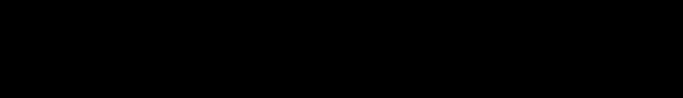
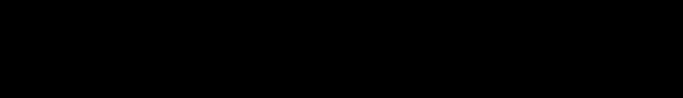

## 1. Setup

Install the package and its dependencies (see `requirements.txt`). A valid **LSEG (Refinitiv) Workspace** session is required, and the path to your LSEG config must be set in `VADER/configuration/config.py`.

In [ ]:
import pandas as pd

from vader.load_data import VaderData

## 2. Instantiate `VaderData`

`VaderData` lazily loads and caches all inputs (prices, market caps, S&P 500 proxy) and derives the intermediate series on first access.

**Parameters**

| Parameter | Type | Default | Description |
|---|---|---|---|
| `start` | `str` | `"2001-01-01"` | Start date of the sample (`YYYY-MM-DD`). |
| `end` | `str` | today | End date of the sample (`YYYY-MM-DD`). |
| `regression_window` | `int` | `252` | Rolling-window length (in trading days) used to estimate market betas. |



In [ ]:
vader_data = VaderData(start="2002-01-01",
                       end="2026-06-01",
                       regression_window=252)

close_prices = vader_data.prices
residual_series = vader_data.residual_series
vader = vader_data.vader


## Notes and troubleshooting

- **LSEG session.** All data are pulled through `lseg.data`. `config["lseg_config_path"]` in `VADER/configuration/config.py` must point to a valid LSEG Workspace configuration.
- **Caching.** Every property (`prices`, `market_caps`, `market_proxy`, `residual_series`, `value_weighted_returns`, `vader`) is computed once and cached on the instance. Re-instantiating `VaderData` reloads from LSEG.
